# 01 - Precipitation (CHIRPS)

Operationalize CHIRPS monthly precipitation into district-level features and run EDA.

In [ ]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

In [ ]:
# Locate repo root early so we can import src modules.

def _find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for parent in [start] + list(start.parents):
        if (parent / "src").exists() and (parent / "data").exists():
            return parent
    raise RuntimeError("Could not locate repo root. Run from within the repo.")


REPO_ROOT = _find_repo_root()
sys.path.append(str(REPO_ROOT / "src"))

from satellites.utils import (
    coverage_report,
    ensure_dir,
    find_repo_root,
    load_ubigeo,
    missingness_table,
    outlier_table,
    plot_corr_heatmap,
    plot_hist_ecdf,
    plot_missingness,
    raster_info,
    read_json,
    safe_read_parquet,
    sample_raster_points,
    select_numeric_columns,
    sum_with_nan,
    write_json,
)

REPO_ROOT = find_repo_root(REPO_ROOT)
np.random.seed(42)

sns.set_theme(style="whitegrid")

In [ ]:
def _show_plot(path: Path, title: str) -> None:
    if not path.exists():
        print(f"[plot missing] {title}: {path}")
        return
    print(f"[plot] {title}: {path}")
    display(Image(filename=str(path)))

## Setup

In [ ]:
RAW_DIR = REPO_ROOT / "data" / "external" / "raw" / "chirps"
MONTHLY_DIR = RAW_DIR / "monthly_tifs"
RAW_META_PATH = RAW_DIR / "metadata.json"

PROCESSED_DIR = REPO_ROOT / "data" / "external" / "processed"
UBIGEO_PATH = PROCESSED_DIR / "ubigeo_district_capitals.parquet"
UBIGEO_FALLBACK = REPO_ROOT / "data" / "external" / "raw" / "ubigeo" / "ubigeo_distrito.csv"
UBIGEO_PLAN_A = REPO_ROOT / "data" / "external" / "raw" / "ubigeo" / "DD_TB_UBIGEOS.xlsx"

REPORT_DIR = ensure_dir(REPO_ROOT / "reports" / "satellites" / "01_precipitation")

RAW_META = read_json(RAW_META_PATH)
TARGET_YEAR = int(RAW_META.get("target_year", 2024))
BASELINE_START = int(RAW_META.get("baseline_start", 2015))
BASELINE_END = int(RAW_META.get("baseline_end", 2020))

WET_MONTHS = [11, 12, 1, 2, 3]
DRY_MONTHS = [5, 6, 7, 8, 9]

OUT_PARQUET = PROCESSED_DIR / f"chirps_district_features_{TARGET_YEAR}.parquet"
OUT_META = REPORT_DIR / "chirps_metadata.json"
QA_SUMMARY_PATH = REPORT_DIR / "qa_summary.json"

## Load UBIGEO and raw metadata

In [ ]:
ubigeo = load_ubigeo(UBIGEO_PATH, UBIGEO_FALLBACK, fallback_excel=UBIGEO_PLAN_A, write_back=True)

print(f"UBIGEO rows: {len(ubigeo)}")
print("Missing capital coordinates:", ubigeo[["capital_lat", "capital_lon"]].isna().any(axis=1).sum())

print("Raw metadata: baseline", BASELINE_START, "to", BASELINE_END)
print("Target year:", TARGET_YEAR)

UBIGEO rows: 1892
Missing capital coordinates: 18
Raw metadata: baseline 2015 to 2020
Target year: 2024


## Load + Raw QA

In [ ]:

def raster_path(year: int, month: int) -> Path:
    return MONTHLY_DIR / str(year) / f"chirps-v2.0.{year}.{month:02d}.tif.gz"


def list_year_files(year: int) -> list[Path]:
    return [raster_path(year, month) for month in range(1, 13)]


baseline_years = list(range(BASELINE_START, BASELINE_END + 1))
all_years = sorted(set(baseline_years + [TARGET_YEAR]))

missing_files = []
for year in all_years:
    files = list_year_files(year)
    missing = [p for p in files if not p.exists()]
    if missing:
        missing_files.extend(missing)
    print(f"{year}: {len(files) - len(missing)} / {len(files)} files present")

if missing_files:
    raise FileNotFoundError(f"Missing CHIRPS files (showing up to 5): {missing_files[:5]}")

sample_info = raster_info(raster_path(TARGET_YEAR, 1), gzip_enabled=True)
print("Sample raster info:", sample_info)

# Basic data contract checks
if sample_info["crs"] is None:
    raise ValueError("CHIRPS raster CRS is missing.")

if sample_info["count"] != 1:
    raise ValueError("Expected single-band CHIRPS monthly rasters.")

if sample_info["bounds"] is None or sample_info["res"] is None:
    raise ValueError("CHIRPS raster bounds/resolution metadata missing.")

if sample_info["nodata"] is None:
    print("Warning: CHIRPS nodata is None; missing values may be under-detected.")

2015: 12 / 12 files present
2016: 12 / 12 files present
2017: 12 / 12 files present
2018: 12 / 12 files present
2019: 12 / 12 files present
2020: 12 / 12 files present
2024: 12 / 12 files present
Sample raster info: {'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]'), 'bounds': BoundingBox(left=-180.0, bottom=-50.00000149011612, right=180.00000536441803, top=50.0), 'res': (0.05000000074505806, 0.05000000074505806), 'nodata': None, 'dtype': 'float32', 'count': 1, 'shape': (2000, 7200)}


## Operationalization / Pre-processing

In [ ]:
valid_mask = ubigeo[["capital_lat", "capital_lon"]].notna().all(axis=1).to_numpy()
coords = list(
    zip(
        ubigeo.loc[valid_mask, "capital_lon"].astype(float),
        ubigeo.loc[valid_mask, "capital_lat"].astype(float),
    )
)


def sample_month(year: int, month: int) -> np.ndarray:
    path = raster_path(year, month)
    values = sample_raster_points(path, coords, gzip_enabled=True)
    if values.size == 0:
        return np.full(len(ubigeo), np.nan)
    values = values[:, 0]
    full = np.full(len(ubigeo), np.nan)
    full[valid_mask] = values
    return full


def season_months(year: int, months: list[int], cross_year: bool = True) -> tuple[list[tuple[int, int]], str]:
    if cross_year and any(m in (11, 12) for m in months):
        pairs = []
        for m in months:
            if m in (11, 12):
                pairs.append((year - 1, m))
            else:
                pairs.append((year, m))
        if all(raster_path(y, m).exists() for y, m in pairs):
            return pairs, "cross_year"
    return [(year, m) for m in months], "within_year"


# Target-year totals
monthly_target = [sample_month(TARGET_YEAR, m) for m in range(1, 13)]
prcp_total = sum_with_nan(monthly_target)

wet_pairs, wet_mode = season_months(TARGET_YEAR, WET_MONTHS, cross_year=True)
wet_vals = sum_with_nan([sample_month(y, m) for y, m in wet_pairs])

# Dry season uses within-year definition
DRY_PAIRS = [(TARGET_YEAR, m) for m in DRY_MONTHS]
dry_vals = sum_with_nan([sample_month(y, m) for y, m in DRY_PAIRS])

# Baseline climatology (annual totals)
baseline_totals = []
for year in baseline_years:
    yearly_months = [sample_month(year, m) for m in range(1, 13)]
    baseline_totals.append(sum_with_nan(yearly_months))

baseline_stack = np.vstack(baseline_totals)
baseline_mean = np.nanmean(baseline_stack, axis=0)
baseline_sd = np.nanstd(baseline_stack, axis=0, ddof=1)

prcp_anom = prcp_total - baseline_mean
prcp_z = np.where(baseline_sd > 0, prcp_anom / baseline_sd, np.nan)

out = pd.DataFrame(
    {
        "ubigeo6": ubigeo["ubigeo6"].astype("string"),
        f"prcp_{TARGET_YEAR}_total": prcp_total,
        f"prcp_{TARGET_YEAR}_wet": wet_vals,
        f"prcp_{TARGET_YEAR}_dry": dry_vals,
        "prcp_baseline_mean": baseline_mean,
        "prcp_baseline_sd": baseline_sd,
        "prcp_total_anom": prcp_anom,
        "prcp_total_z": prcp_z,
    }
)

if not out["ubigeo6"].is_unique:
    raise ValueError("Output ubigeo6 keys are not unique.")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
out.to_parquet(OUT_PARQUET, index=False)
print(f"Wrote {OUT_PARQUET}")

meta = {
    "source": "CHIRPS v2 monthly precipitation",
    "target_year": TARGET_YEAR,
    "baseline_start": BASELINE_START,
    "baseline_end": BASELINE_END,
    "baseline_note": RAW_META.get("baseline_note"),
    "season_definitions": {
        "wet": "Nov-Mar",
        "dry": "May-Sep",
        "wet_mode": wet_mode,
    },
    "units": {
        f"prcp_{TARGET_YEAR}_total": "mm/year",
        f"prcp_{TARGET_YEAR}_wet": "mm/season",
        f"prcp_{TARGET_YEAR}_dry": "mm/season",
        "prcp_baseline_mean": "mm/year",
        "prcp_baseline_sd": "mm/year",
        "prcp_total_anom": "mm/year",
        "prcp_total_z": "z-score",
    },
    "nodata": sample_info["nodata"],
    "crs": str(sample_info["crs"]),
    "resolution": sample_info["res"],
}

write_json(OUT_META, meta)

# Also keep processed metadata aligned with existing convention
processed_meta = RAW_META.copy()
processed_meta.update(meta)
write_json(PROCESSED_DIR / "chirps_metadata.json", processed_meta)

Wrote /Users/gabrielsaco/Documents/GitHub/sfa_ciup/data/external/processed/chirps_district_features_2024.parquet


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_9134/1084893074.py:52: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(baseline_stack, axis=0)
/Users/gabrielsaco/Documents/GitHub/sfa_ciup/venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
ERROR 1: PROJ: internal_proj_identify: /Users/gabrielsaco/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


## QA summary

In [ ]:
missing_table = missingness_table(out)
summary_stats = out[select_numeric_columns(out, exclude=["ubigeo6"])].describe().T[
    ["min", "max", "mean", "std"]
]
coverage_table, missing_keys = coverage_report(out, ubigeo)

qa_summary = {
    "row_count": int(len(out)),
    "ubigeo_unique": bool(out["ubigeo6"].is_unique),
    "missing_keys": missing_keys[:50],
    "missing_key_count": int(len(missing_keys)),
    "missingness": missing_table.to_dict(orient="records"),
    "summary_stats": summary_stats.reset_index().rename(columns={"index": "feature"}).to_dict(orient="records"),
    "coverage": coverage_table.to_dict(orient="records"),
}

write_json(QA_SUMMARY_PATH, qa_summary)
print(f"Wrote {QA_SUMMARY_PATH}")

Wrote /Users/gabrielsaco/Documents/GitHub/sfa_ciup/reports/satellites/01_precipitation/qa_summary.json


## EDA outputs

[plot] Missingness by column: /Users/gabrielsaco/Documents/GitHub/sfa_ciup/reports/satellites/01_precipitation/missingness_plot.png


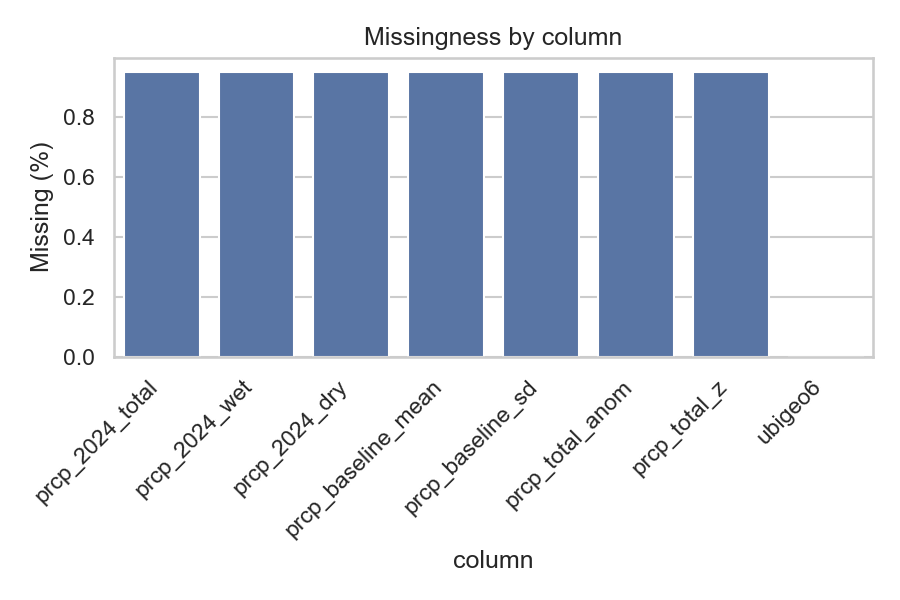

[plot] Feature distributions: /Users/gabrielsaco/Documents/GitHub/sfa_ciup/reports/satellites/01_precipitation/feature_distributions.png


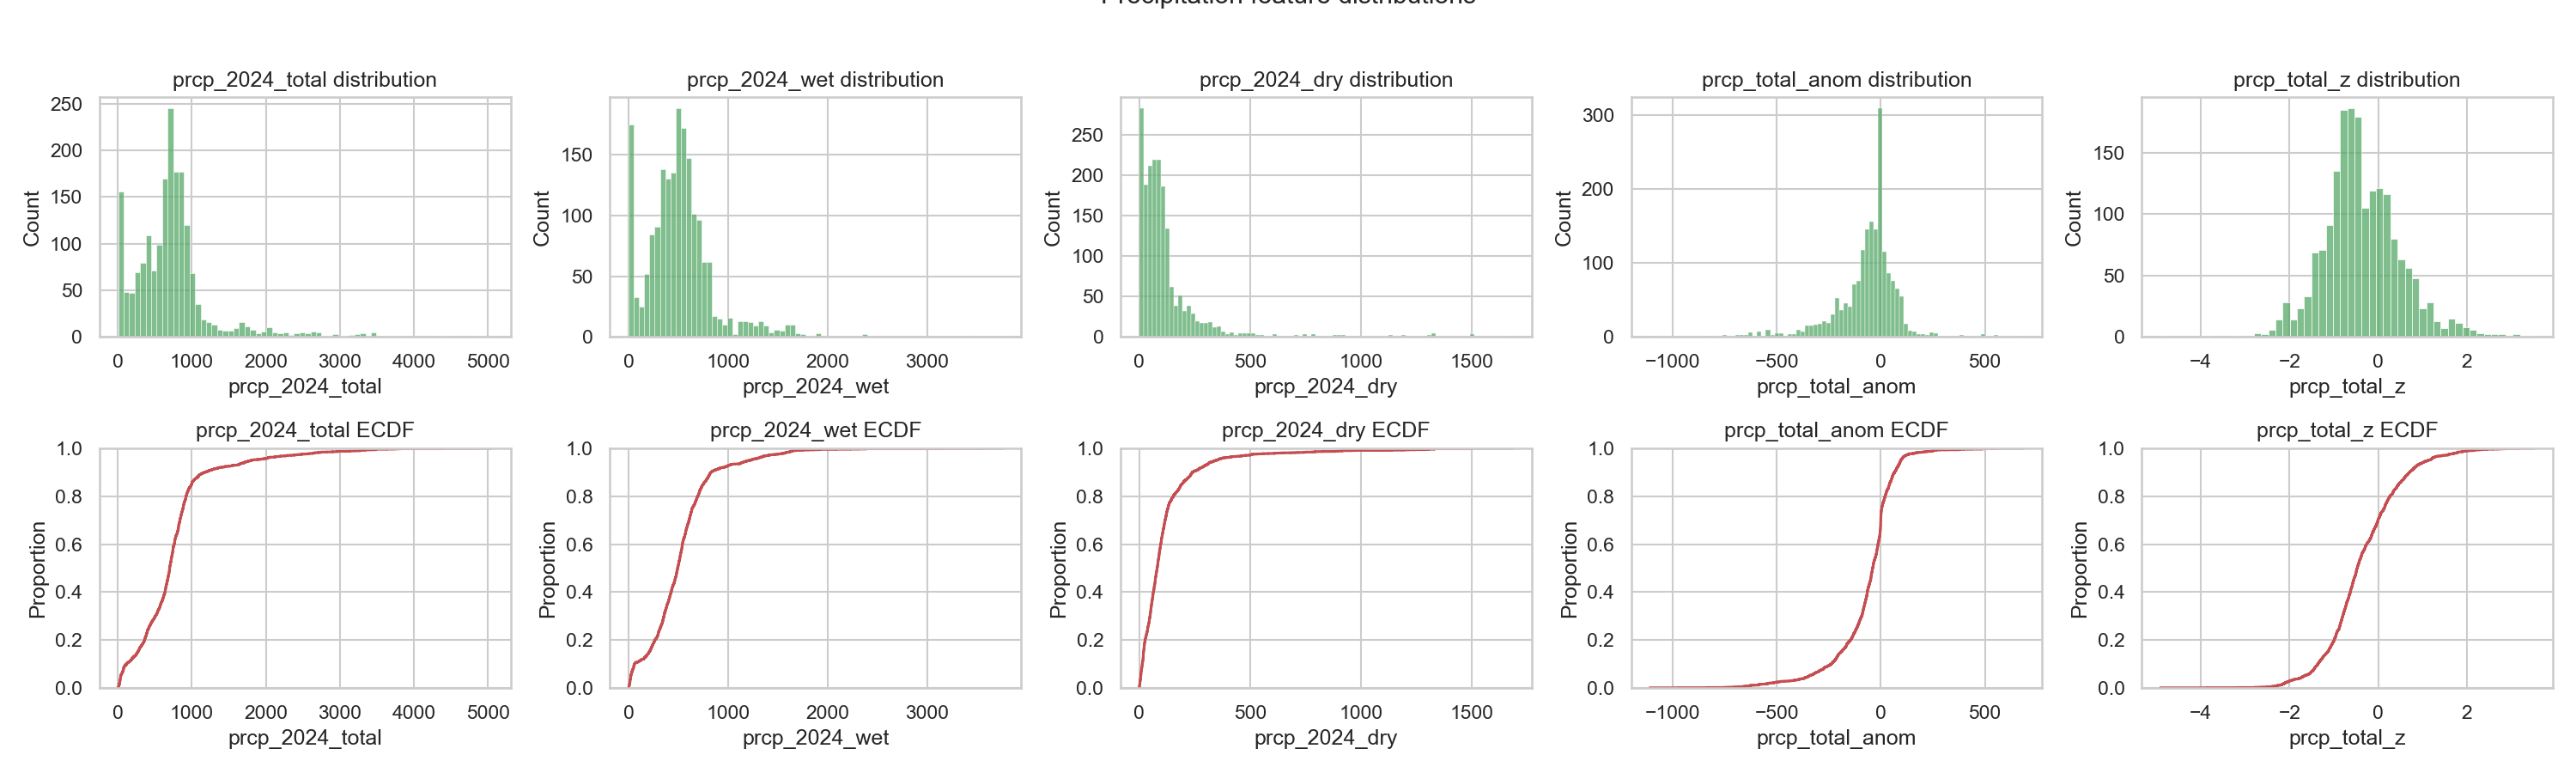

[plot] Precipitation correlations: /Users/gabrielsaco/Documents/GitHub/sfa_ciup/reports/satellites/01_precipitation/corr_precip_only.png


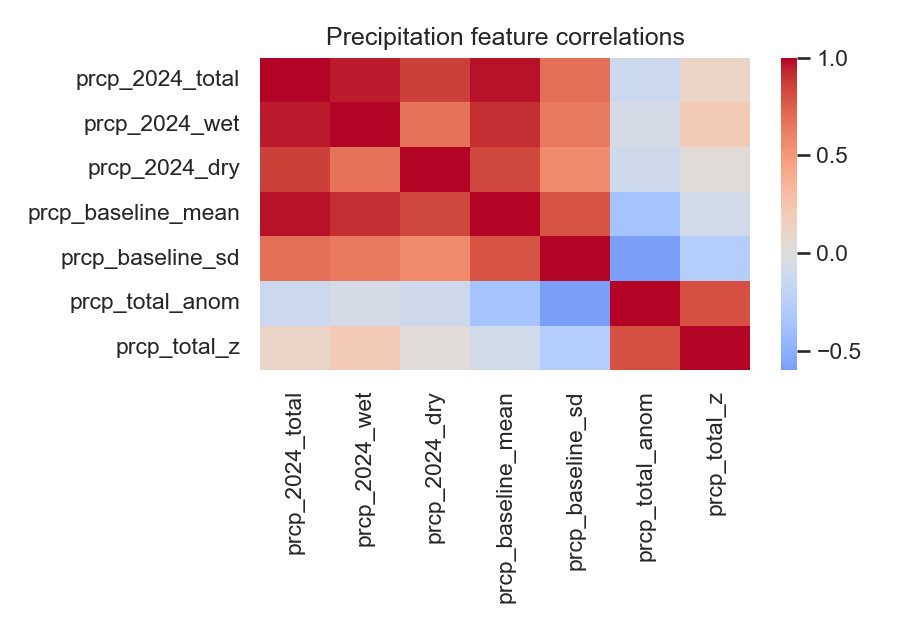

[plot] Precipitation + other satellites: /Users/gabrielsaco/Documents/GitHub/sfa_ciup/reports/satellites/01_precipitation/corr_with_other_satellites.png


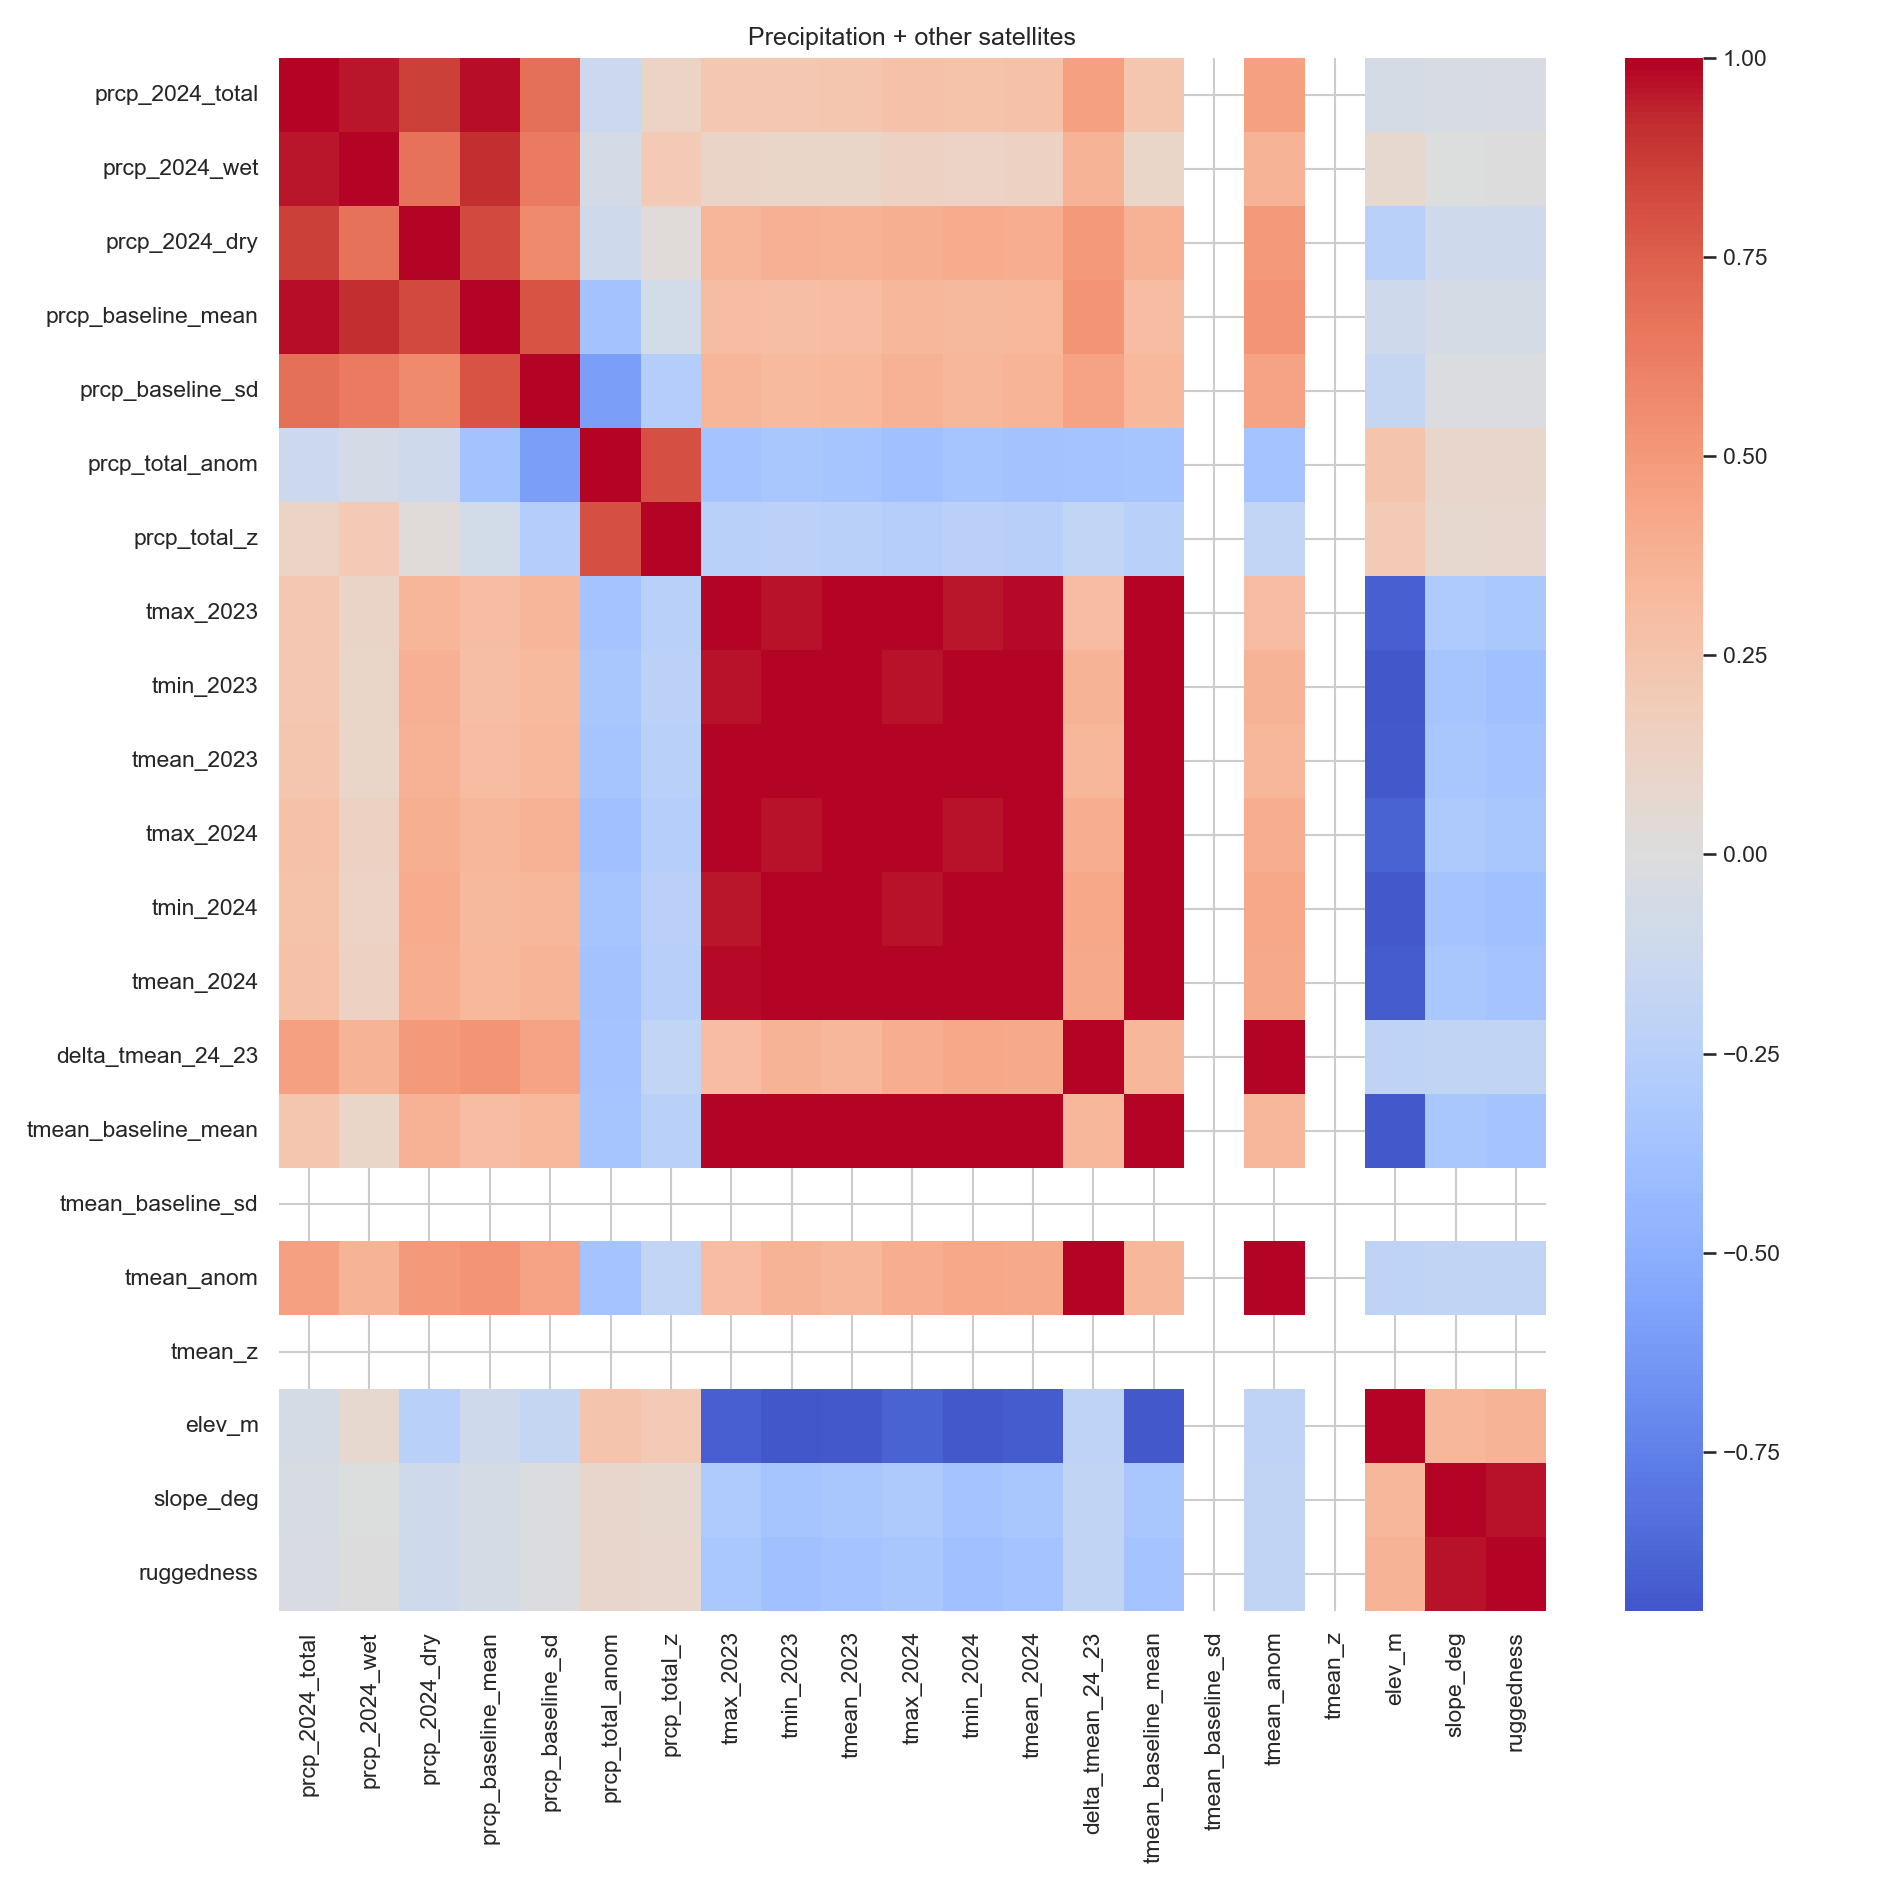

In [ ]:
missing_table_path = REPORT_DIR / "missingness_table.csv"
missing_table.to_csv(missing_table_path, index=False)
plot_missingness(missing_table, REPORT_DIR / "missingness_plot.png", "Missingness by column")
_show_plot(REPORT_DIR / "missingness_plot.png", "Missingness by column")

key_features = [
    f"prcp_{TARGET_YEAR}_total",
    f"prcp_{TARGET_YEAR}_wet",
    f"prcp_{TARGET_YEAR}_dry",
    "prcp_total_anom",
    "prcp_total_z",
]
plot_hist_ecdf(out, key_features, REPORT_DIR / "feature_distributions.png", "Precipitation feature distributions")
_show_plot(REPORT_DIR / "feature_distributions.png", "Feature distributions")

outliers = outlier_table(out, key_features)
outliers.to_csv(REPORT_DIR / "outliers_top_bottom_20.csv", index=False)

coverage_table.to_csv(REPORT_DIR / "coverage_report.csv", index=False)

# Correlations within precipitation features
corr = out[select_numeric_columns(out, exclude=["ubigeo6"])].corr()
plot_corr_heatmap(corr, REPORT_DIR / "corr_precip_only.png", "Precipitation feature correlations")
_show_plot(REPORT_DIR / "corr_precip_only.png", "Precipitation correlations")

# Correlation with other satellite features if available
other_paths = {
    "temperature": PROCESSED_DIR / "temperature_district_features_2023_2024.parquet",
    "topography": PROCESSED_DIR / "topography_district_features.parquet",
}

other_frames = []
for name, path in other_paths.items():
    df = safe_read_parquet(path, required=False)
    if df is not None:
        other_frames.append(df)

if other_frames:
    merged = out.copy()
    for df in other_frames:
        merged = merged.merge(df, on="ubigeo6", how="left")
    corr_all = merged[select_numeric_columns(merged, exclude=["ubigeo6"])].corr()
    plot_corr_heatmap(corr_all, REPORT_DIR / "corr_with_other_satellites.png", "Precipitation + other satellites")
    _show_plot(REPORT_DIR / "corr_with_other_satellites.png", "Precipitation + other satellites")

## End-of-notebook checklist

In [ ]:
print("Output parquet:", OUT_PARQUET)
print("Report folder:", REPORT_DIR)
print("Summary:")
print(f"- Computed CHIRPS totals for {TARGET_YEAR} with wet/dry season splits")
print(f"- Baseline climatology: {BASELINE_START}-{BASELINE_END} (wet mode: {wet_mode})")
print("- Units: precipitation in mm, anomalies in mm, z-scores unitless")
print("- Caveats: missing capital coordinates or raster nodata yield NaN")

Output parquet: /Users/gabrielsaco/Documents/GitHub/sfa_ciup/data/external/processed/chirps_district_features_2024.parquet
Report folder: /Users/gabrielsaco/Documents/GitHub/sfa_ciup/reports/satellites/01_precipitation
Summary:
- Computed CHIRPS totals for 2024 with wet/dry season splits
- Baseline climatology: 2015-2020 (wet mode: within_year)
- Units: precipitation in mm, anomalies in mm, z-scores unitless
- Caveats: missing capital coordinates or raster nodata yield NaN
